In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
data_path = '../data/'

groupID1 = np.genfromtxt(data_path + 'iDESIDR9_SGC_1', delimiter=None, dtype=np.int32, usecols=[1])
groupID2 = np.genfromtxt(data_path + 'iDESIDR9_NGC_1', delimiter=None, dtype=np.int32, usecols=[1])


In [4]:
Igro1,Nmem1=np.unique(groupID1,return_counts=True)
Igro2,Nmem2=np.unique(groupID2,return_counts=True)

In [5]:
Ngro1=Nmem1.shape[0]
Ngro2=Nmem2.shape[0]
Ngro=Ngro1+Ngro2
print(Ngro,'DESI DR9 groups')

91739237 DESI DR9 groups


In [6]:
def is_prime(n):
    n = int(n)  # Ensure n is an integer
    if n <= 1:
        return False
    for i in range(2, int(n**0.5) + 1):
        if n % i == 0:
            return False
    return True

def fraction_of_primes_in_range(n_th, n_max):
    if n_th >= n_max:
        return 0.0
    prime_count = sum(is_prime(n) for n in range(n_th, n_max + 1))
    total_count = n_max - n_th + 1
    return prime_count / total_count

In [ ]:
import numpy as np
from scipy.special import zeta, factorial

def riemann_r(x, terms=100):
    """
    Computes Riemann's R(x) function using the Gram series.
    
    Parameters:
        x (float): The value to evaluate.
        terms (int): Number of terms in the series (usually 50-100 is sufficient).
    """
    if x < 2:
        return 0
    
    ln_x = np.log(x)
    r_sum = 1.0  # The initial 1 in the Gram series
    
    for n in range(1, terms + 1):
        # Formula: (ln(x)^n) / (n * n! * zeta(n+1))
        term = (ln_x**n) / (n * factorial(n) * zeta(n + 1))
        r_sum += term
        
    return r_sum

# Example Usage:
x_val = 10**6
approx = riemann_r(x_val)

print(f"R({x_val}) ≈ {approx:.4f}")
print(f"Actual π(10^6) = 78498")
print(f"Difference: {abs(78498 - approx):.4f}")


def fraction_of_primes_in_range_riemann_r(n_th, n_max):
    return (riemann_r(n_max) - riemann_r(n_th - 1))/(n_max - n_th + 1)

R(1000000) ≈ 78527.3994
Actual π(10^6) = 78498
Difference: 29.3994


(0.33409200021337504, 0.26666666666666666, 75156)
(0.25869859918662447, 0.23333333333333334, 2290)
(0.2222222222222222, 0.2, 414)
(0.33228235419327373, 0.26666666666666666, 74931)
(0.2623706702654071, 0.23333333333333334, 2333)
(0.23246287762416795, 0.2, 454)


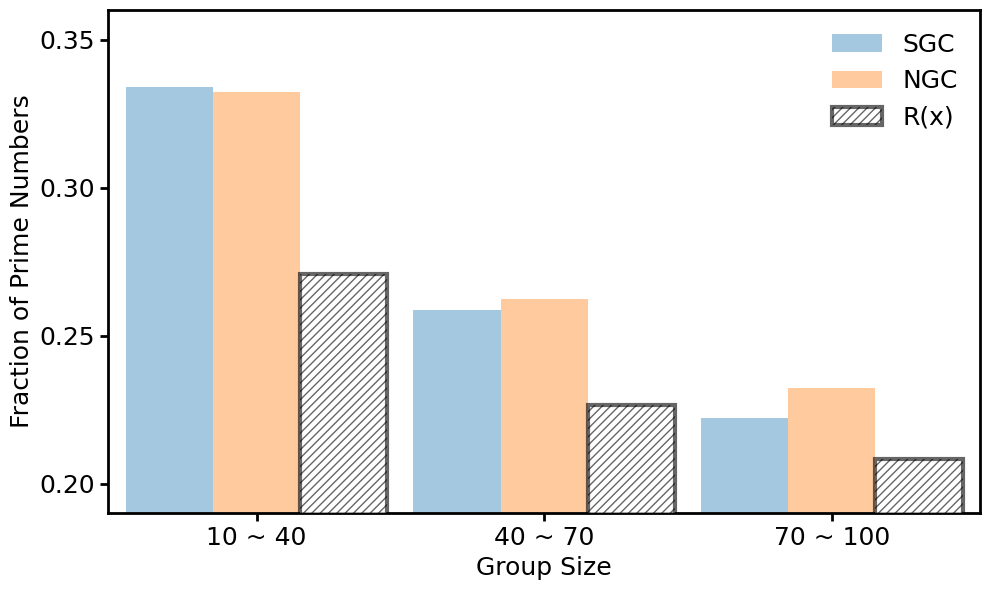

In [12]:
# nbins = 10
# n_bin_center_array = np.zeros(nbins)
# fraction_prime1_array = np.zeros(nbins)
# fraction_prime1_flat_array = np.zeros(nbins)

n_mem_min_1 = 10
n_mem_max_1 = 40

def primes_members_in_range(n_mem_min, n_mem_max, Nmem_in):
        sel = np.where((Nmem_in >= n_mem_min) & (Nmem_in < n_mem_max))
        Nsel=Nmem_in[sel]
        fraction_prime = sum(is_prime(n) for n in Nsel) / len(Nsel)
        fraction_prime_flat = fraction_of_primes_in_range(n_mem_min, n_mem_max - 1)
        return fraction_prime, fraction_prime_flat, sum(is_prime(n) for n in Nsel)

# sel1 = np.where((Nmem1 >= n_mem_min_1) & (Nmem1 < n_mem_max_1))
# Nsel1=Nmem1[sel1]
# n_bin_center = (n_mem_min_1 + n_mem_max_1) / 2
# fraction_prime1 = sum(is_prime(n) for n in Nsel1) / len(Nsel1)
# fraction_prime1_flat = fraction_of_primes_in_range(n_mem_min_1, n_mem_max_1 - 1)


print(primes_members_in_range(10, 40, Nmem1))
print(primes_members_in_range(40, 70, Nmem1))
print(primes_members_in_range(70, 100, Nmem1))


print(primes_members_in_range(10, 40, Nmem2))
print(primes_members_in_range(40, 70, Nmem2))
print(primes_members_in_range(70, 100, Nmem2))

import matplotlib as mpl
mpl.rcParams['axes.linewidth'] = 2

# Set global tick width for major x and y ticks
mpl.rcParams['xtick.major.width'] = 2
mpl.rcParams['ytick.major.width'] = 2

# Optionally, set size (length)
mpl.rcParams['xtick.major.size'] = 6
mpl.rcParams['ytick.major.size'] = 6

# For minor ticks
mpl.rcParams['xtick.minor.width'] = 0
mpl.rcParams['ytick.minor.width'] = 0

plt.figure(figsize=(10, 6), edgecolor='k', tight_layout=True)
plt.bar([7, 40, 73], 
        [primes_members_in_range(10, 40, Nmem1)[0], 
         primes_members_in_range(40, 70, Nmem1)[0], 
         primes_members_in_range(70, 100, Nmem1)[0]], 
         color=['C0', 'C0','C0'], label='SGC', alpha=0.4, width=10, align='center')
plt.bar([17, 50, 83], 
        [primes_members_in_range(10, 40, Nmem2)[0], 
         primes_members_in_range(40, 70, Nmem2)[0], 
         primes_members_in_range(70, 100, Nmem2)[0]], 
         color=['C1', 'C1','C1'], label='NGC', alpha=0.4, width=10, align='center')
# plt.bar([17, 50, 83], 
#          [primes_members_in_range(10, 40, Nmem1)[1], 
#           primes_members_in_range(40, 70, Nmem1)[1], 
#           primes_members_in_range(70, 100, Nmem1)[1]], 
#           color=['w','w','w'], label='R(x)', alpha=0.6, width=30, align='center', 
#           hatch='////', edgecolor='k', linewidth=3, zorder=3
#           )

plt.bar([27, 60, 93], 
         [fraction_of_primes_in_range_riemann_r(10, 40), 
          fraction_of_primes_in_range_riemann_r(40, 70), 
          fraction_of_primes_in_range_riemann_r(70, 100)], 
          color=['w','w','w'], label='R(x)', alpha=0.6, width=10, align='center', 
          hatch='////', edgecolor='k', linewidth=3, zorder=3
          )

# plt.bar([17, 50, 83], [riemann_r(i)/i for i in range(10, 100)], 
#                        'r--', label='Riemann')

plt.xlim(0, 100)
plt.ylim(0.19, 0.36)
plt.xlabel('Group Size', fontsize=18)
plt.ylabel('Fraction of Prime Numbers', fontsize=18)
# plt.title('Prime Number Fraction vs Group Size', fontsize=18)                
# numeric tick positions + text labels
plt.xticks([17, 50, 83], ['10 ~ 40', '40 ~ 70', '70 ~ 100'], fontsize=18)
plt.yticks([0.20, 0.25, 0.30, 0.35], fontsize=18)
plt.legend(frameon=False, fontsize=18, loc='upper right', ncol=1)
plt.savefig('../plots/prime_fraction_vs_group_size.pdf', dpi=300)
plt.show()

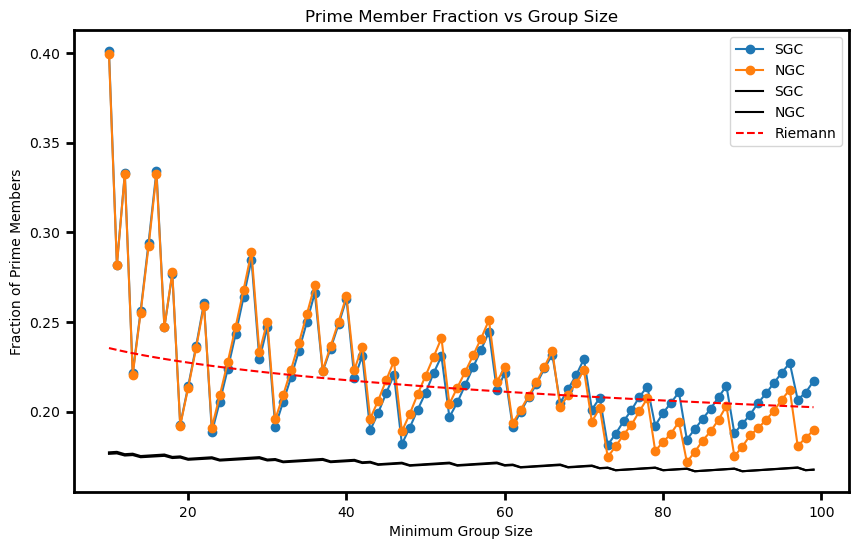

In [9]:
n_th1_list = []
fraction_prime1_list = []
fraction_prime1_flat_list = []
n_mem_max_1 = 100

for n_th in range(10, n_mem_max_1):
    sel1=np.where(Nmem1 > n_th)
    Nsel1=Nmem1[sel1]
    n_th1_list.append(n_th)
    n_prime1_count = sum(is_prime(n) for n in Nsel1)
    fraction_prime1 = n_prime1_count / len(Nsel1)
    fraction_prime1_list.append(fraction_prime1)
    fraction_prime1_flat = fraction_of_primes_in_range(n_th, Nsel1.max())
    fraction_prime1_flat_list.append(fraction_prime1_flat)

n_th1_array = np.array(n_th1_list)
fraction_prime1_array = np.array(fraction_prime1_list)
fraction_prime1_flat_array = np.array(fraction_prime1_flat_list)



n_th2_list = []
fraction_prime2_list = []
fraction_prime2_flat_list = []
n_mem_max_2 = 100

for n_th in range(10, n_mem_max_2):
    sel2=np.where(Nmem2 > n_th)
    Nsel2=Nmem2[sel2]
    n_th2_list.append(n_th)
    n_prime2_count = sum(is_prime(n) for n in Nsel2)
    fraction_prime2 = n_prime2_count / len(Nsel2)
    fraction_prime2_list.append(fraction_prime2)
    fraction_prime2_flat = fraction_of_primes_in_range(n_th, Nsel2.max())
    fraction_prime2_flat_list.append(fraction_prime2_flat)

n_th2_array = np.array(n_th2_list)
fraction_prime2_array = np.array(fraction_prime2_list)
fraction_prime2_flat_array = np.array(fraction_prime2_flat_list)

plt.figure(figsize=(10, 6))
plt.plot(n_th1_array, fraction_prime1_array, 'C0-o', label='SGC')
plt.plot(n_th2_array, fraction_prime2_array, 'C1-o', label='NGC')
plt.plot(n_th1_array, fraction_prime1_flat_array, 'k-', label='SGC')
plt.plot(n_th2_array, fraction_prime2_flat_array, 'k-', label='NGC')
plt.plot(n_th1_array, 
         [fraction_of_primes_in_range_theoretical(n_th, n_mem_max_1) for n_th in n_th1_array], 
         'r--', label='Riemann')
plt.xlabel('Minimum Group Size')
plt.ylabel('Fraction of Prime Members')
plt.title('Prime Member Fraction vs Group Size')
plt.legend()
plt.show()

In [43]:

odd_values = Nsel1[Nsel1 % 2 != 0]
Nodd1=len(odd_values)
print(Nodd1,'odd member groups in SGC')

odd_values = Nsel2[Nsel2 % 2 != 0]
Nodd2=len(odd_values)
print(Nodd2,'odd member groups in NGC')


162897 odd member groups in SGC
163653 odd member groups in NGC


In [44]:
even_values = Nsel1[Nsel1 % 2 == 0]
Neven1=len(even_values)
print(Neven1,'even member groups in SGC')

even_values = Nsel2[Nsel2 % 2 == 0]
Neven2=len(even_values)
print(Neven2,'even member groups in NGC')


130125 even member groups in SGC
131134 even member groups in NGC


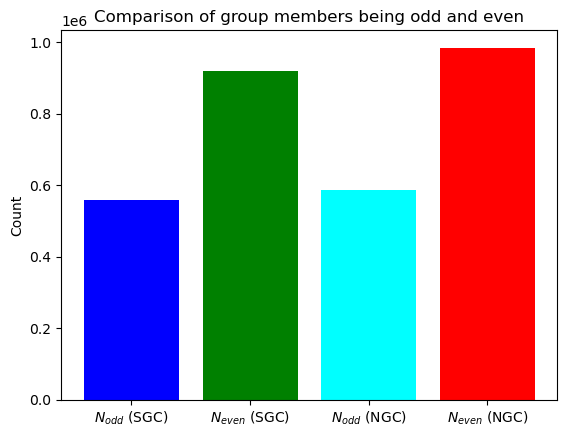

In [23]:
# Data for the bar plot
categories = ['$N_{odd}$ (SGC)', '$N_{even}$ (SGC)','$N_{odd}$ (NGC)', '$N_{even}$ (NGC)' ]
values = [Nodd1, Neven1, Nodd2, Neven2]

# Create the bar plot
plt.bar(categories, values, color=['blue', 'green','cyan','red'])
plt.ylabel('Count')
plt.title('Comparison of group members being odd and even')
plt.savefig('odd_even.png',format='png')
plt.show()
plt.close()

Text(0.5, 0, 'group members')

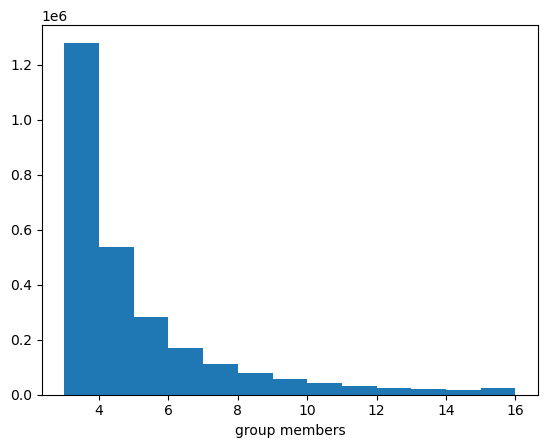

In [24]:
# the reason for the higher number of odd member groups is simply that 
# there are always less number of higher member groups in the hierarchica clustering universe.

plt.hist(Nmem1,range=[3,16],bins=13)
plt.xlabel('group members')